# Visualize spatial and temporal patterns in the inspections data

In [1]:
import os
import sys

import contextily as ctx
import geopandas as gpd
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap

sys.path.append("../utils")

import config

pd.set_option("display.max_columns", None)

## Import cleaned inspections data (2019-2023)

In [2]:
# Function to read in inspections data for 2019-2023
def import_inspections_data(year):
    """
    Function to read in inspections data for a given year and convert to Albers CRS.
    """
    inspections = os.path.join(
        config.cleaned_inspections_dir, f"inspections_{year}.geojson"
    )
    inspections = gpd.read_file(inspections).to_crs(config.albers_crs)
    return inspections


# Read in inspection data for 2019-2023 as separate dataframes
inspections_dict = {}
for year in range(2019, 2024):
    inspections_dict[year] = import_inspections_data(year)

In [3]:
# Unpack from dictionary
inspections_2019 = inspections_dict[2019]
inspections_2020 = inspections_dict[2020]
inspections_2021 = inspections_dict[2021]
inspections_2022 = inspections_dict[2022]
inspections_2023 = inspections_dict[2023]

## Join inspections to parcel data

### Drop `apn` variable from inspections data

Some of the inspections data appear to have assessor parcel numbers (APNs). However, because we will join the inspections data to parcel data obtained from Santa Barbara County, we will preserve the APNs associated with the parcel data instead.

In [4]:
# Find all columns with 'apn' in the name and check unique values for all inspection years
for year in range(2019, 2024):
    inspections = eval(f"inspections_{year}")
    apn_columns = inspections.columns[inspections.columns.str.contains("apn")]
    print(f"Year: {year}")
    print(f"{inspections[apn_columns].nunique()}\n")

Year: 2019
apn    0
dtype: int64

Year: 2020
apn    0
dtype: int64

Year: 2021
apn    103
dtype: int64

Year: 2022
apn    155
dtype: int64

Year: 2023
apn    154
dtype: int64



In [5]:
# Drop columns with `apn` in the name for all inspection years
for year in range(2019, 2024):
    inspections = eval(f"inspections_{year}")
    apn_columns = inspections.columns[inspections.columns.str.contains("apn")]
    inspections.drop(columns=apn_columns, inplace=True)

In [6]:
# Confirm that `apn` columns have been dropped
for year in range(2019, 2024):
    inspections = eval(f"inspections_{year}")
    apn_columns = inspections.columns[inspections.columns.str.contains("apn")]
    print(f"Year: {year}")
    print(f"{inspections[apn_columns].nunique()}\n")

Year: 2019
Series([], dtype: float64)

Year: 2020
Series([], dtype: float64)

Year: 2021
Series([], dtype: float64)

Year: 2022
Series([], dtype: float64)

Year: 2023
Series([], dtype: float64)



### Import parcel data (2024)

In [7]:
parcels_2024 = os.path.join(
    config.data_dir,
    "Parcel_Maps_SpatialIndex_2024",
    "Parcel_Maps.shp",
)
parcels_2024 = gpd.read_file(parcels_2024)

### Import Parcel Data (2020)

In [8]:
# Read in complete parcels data and convert to Albers CRS
parcels = os.path.join(config.data_dir, "parcel_boundaries", "cbiinputs.gdb")
parcels = gpd.read_file(parcels).to_crs(config.albers_crs)

### Join inspections data to parcels for each year

In [9]:
def join_parcels_to_inspections(year):
    """
    Function to join inspections data to parcels data for a given year
    while preserving both geometries.
    """
    # Get the inspections GeoDataFrame for this year
    inspections_df = inspections_dict[year]

    # Make a copy of the geometry columns with new names
    parcels_copy = parcels.copy()
    inspections_copy = inspections_df.copy()

    parcels_copy["parcel_geometry"] = parcels_copy.geometry
    inspections_copy["inspection_geometry"] = inspections_copy.geometry

    # Perform the spatial join
    joined = gpd.sjoin(
        parcels_copy, inspections_copy, how="inner", predicate="contains"
    )

    # Rename columns for clarity
    joined = joined.rename(
        columns={
            "geometry": "intersection_geometry",  # intersection of parcel and inspection
            "parcel_geometry": "geometry",
        }
    )

    # Set the primary geometry to the parcel geometry
    joined = joined.set_geometry("geometry")

    return joined


# Join inspections data to parcels data for 2019-2023
joined_dict = {}
for year in range(2019, 2024):
    joined_dict[year] = join_parcels_to_inspections(year)


In [10]:
# Unpack joined data from dictionary
joined_2019 = joined_dict[2019]
joined_2020 = joined_dict[2020]
joined_2021 = joined_dict[2021]
joined_2022 = joined_dict[2022]
joined_2023 = joined_dict[2023]

In [11]:
# Check shape of joined dataframes
(
    joined_2019.shape,
    joined_2020.shape,
    joined_2021.shape,
    joined_2022.shape,
    joined_2023.shape,
)

((14847, 313), (11970, 313), (14182, 313), (13809, 313), (13544, 313))

### Plot parcel boundaries and inspections for each year

In [12]:
# # Create a function that plots the joined data and inspections for each year
# def plot_inspections(year):
#     """
#     Function to plot the joined data and inspections for a given year.
#     """
#     fig, ax = plt.subplots(figsize=(10, 6))

#     # Plot the joined data
#     globals()[f"joined_{year}"].boundary.plot(
#         ax=ax, color="purple", linewidth=0.4, alpha=0.5
#     )

#     # Plot the inspections data
#     globals()[f"inspections_{year}"].plot(
#         ax=ax, color="red", markersize=0.5, alpha=0.75
#     )

#     plt.title(f"{year} Inspections and Parcel Boundaries")
#     plt.show()


# # Plot inspections for each year
# for year in range(2019, 2024):
#     plot_inspections(year)

## Plot non-compliant inspections with roads

In [13]:
# Import counties shapefile and filter to Santa Barbara County
counties = gpd.read_file(
    os.path.join(config.data_dir, "ca_counties", "CA_Counties.shp")
)
counties = counties.to_crs(config.geodetic_crs)
sb_county = counties.loc[counties["NAME"] == "Santa Barbara"]

# Create bounding box to remove channel islands
bbox = [-125, 34.25, -119.0, 38.0]
sb_county = sb_county.clip(bbox)

# Convert to Albers CRS
sb_county = sb_county.to_crs(config.albers_crs)

# Save to file
sb_county.to_file(
    os.path.join(config.data_dir, "ca_counties", "sb_county_boundary.shp")
)

/Users/rubinstein/.conda/envs/wildfire_prep/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 7084063392 of field ALAND of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/Users/rubinstein/.conda/envs/wildfire_prep/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 2729751706 of field AWATER of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/Users/rubinstein/.conda/envs/wildfire_prep/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 14498407802.299999 of field Shape_Area of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


In [14]:
# Import sb county roads
roads = os.path.join(
    config.data_dir, "ca_counties", "tl_2023_06083_roads", "tl_2023_06083_roads.shp"
)
roads = gpd.read_file(roads).to_crs(config.albers_crs)

# Remove roads where the longitude is less than -420000 to exclude the Channel Islands
roads = roads[roads.geometry.centroid.y > -420000]

In [15]:
# # Combine all years into a single DataFrame with a 'year' column
# def create_combined_df(years):
#     """
#     Combines data from multiple years into a single DataFrame with a year column.
#     """
#     combined_parcels = []
#     combined_inspections = []

#     for year in years:
#         # Get the joined parcels data and add year column
#         parcels_df = globals()[f"joined_{year}"].copy()
#         parcels_df["year"] = year
#         parcels_df["data_type"] = "parcel"
#         combined_parcels.append(parcels_df)

#         # Get the inspections data and add year column
#         insp_df = globals()[f"inspections_{year}"].copy()
#         insp_df["year"] = year
#         insp_df["data_type"] = "inspection"
#         # Filter for only Non-Compliant status
#         insp_df = insp_df[insp_df["status"] == "Non-Compliant"]

#         combined_inspections.append(insp_df)

#     # Combine all years
#     all_parcels = pd.concat(combined_parcels)
#     all_inspections = pd.concat(combined_inspections)

#     return all_parcels, all_inspections


# # Create a function to plot using seaborn FacetGrid
# def plot_with_facetgrid(years):
#     """
#     Plot inspections and parcels using seaborn FacetGrid.
#     """
#     all_parcels, all_inspections = create_combined_df(years)

#     # Create FacetGrid for parcels
#     g = sns.FacetGrid(
#         all_parcels, col="year", col_wrap=3, height=5, sharex=False, sharey=False
#     )

#     # Define a mapping function that plots both parcels and inspections
#     def plot_both(data, **kwargs):
#         year = data["year"].iloc[0]
#         # Plot parcels
#         ax = plt.gca()
#         sb_county.boundary.plot(ax=ax, color="black", linewidth=0.4)
#         roads.plot(ax=ax, color="purple", linewidth=0.3, alpha=0.2)
#         # Plot inspections for this year
#         insp = all_inspections[all_inspections["year"] == year]
#         insp.plot(ax=ax, color="red", markersize=2)
#         ax.set_axis_off()

#     # Apply the mapping function
#     g.map_dataframe(plot_both)

#     # Add titles
#     g.set_titles("{col_name}")
#     plt.suptitle("Non-Compliant Inspections by Year", fontsize=16, y=1.02)
#     plt.show()


# # Plot using FacetGrid
# plot_with_facetgrid(range(2019, 2024))

## Plot non-compliant inspections with a basemap

In [16]:
# # Create a function to plot using seaborn FacetGrid with basemap
# def plot_with_facetgrid_basemap(years):
#     """
#     Plot inspections and parcels using seaborn FacetGrid with a basemap.
#     """
#     all_parcels, all_inspections = create_combined_df(years)

#     # Create FacetGrid for parcels
#     g = sns.FacetGrid(
#         all_parcels, col="year", col_wrap=3, height=5, sharex=False, sharey=False
#     )

#     # Define a mapping function that plots both parcels and inspections with basemap
#     def plot_both(data, **kwargs):
#         year = data["year"].iloc[0]
#         ax = plt.gca()

#         # Ensure data is in the correct CRS for web map tiles (EPSG:3857)
#         parcels_3857 = data.to_crs(epsg=3857)

#         # Plot inspections for this year
#         insp = all_inspections[all_inspections["year"] == year]
#         insp_3857 = insp.to_crs(epsg=3857)
#         insp_3857.plot(ax=ax, color="red", markersize=2)

#         # Add county boundary
#         sb_county.to_crs(epsg=3857).boundary.plot(ax=ax, color="black", linewidth=0.4)

#         # Add basemap
#         ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

#         # Set title for this subplot
#         ax.set_title(f"Year: {year}")

#         # Remove axis
#         ax.axis("off")

#     # Apply the mapping function
#     g.map_dataframe(plot_both)

#     # Add overall title
#     plt.suptitle("Non-Compliant Inspections by Year", fontsize=16, y=1.02)

#     # Adjust layout
#     plt.tight_layout()
#     plt.show()


# # Plot using FacetGrid with basemap
# plot_with_facetgrid_basemap(range(2019, 2024))

## Plot all inspections by compliance status and year

/tmp/ipykernel_2240986/2144648745.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_parcels = pd.concat(combined_parcels)
/tmp/ipykernel_2240986/2144648745.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_parcels = pd.concat(combined_parcels)
/tmp/ipykernel_2240986/2144648745.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result d

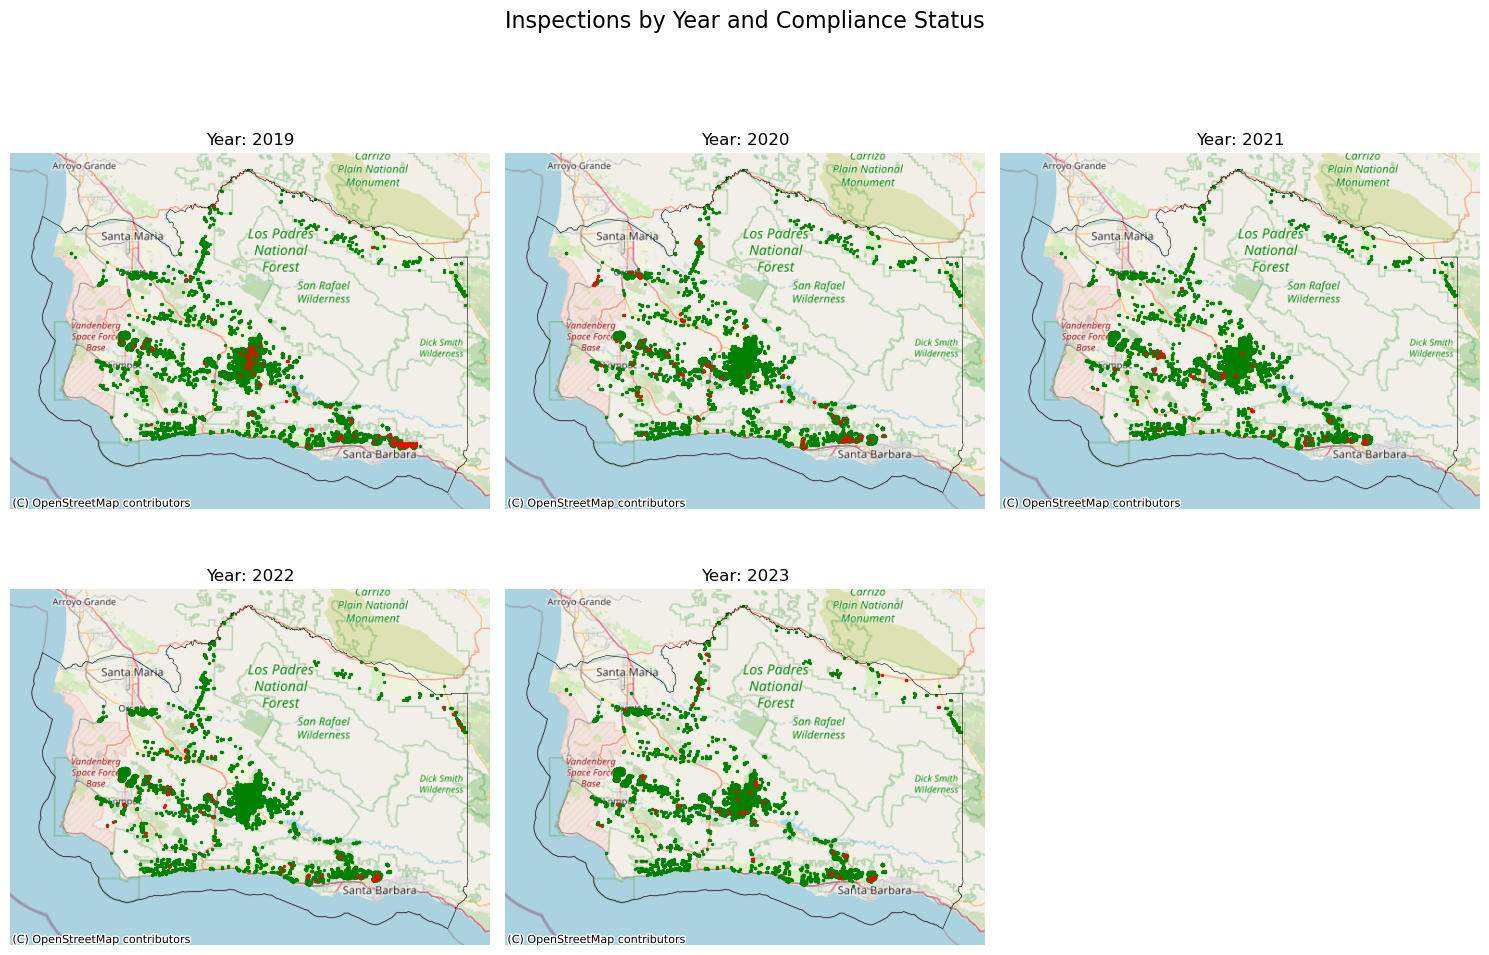

In [17]:
# Create a function to plot using seaborn FacetGrid with basemap
def plot_with_facetgrid_basemap(years):
    """
    Plot inspections and parcels using seaborn FacetGrid with a basemap.
    Shows compliant inspections in green and non-compliant ones in red.
    """
    combined_parcels = []
    combined_inspections = []

    for year in years:
        # Get the joined parcels data and add year column
        parcels_df = globals()[f"joined_{year}"].copy()
        parcels_df["year"] = year
        parcels_df["data_type"] = "parcel"
        combined_parcels.append(parcels_df)

        # Get the inspections data and add year column
        insp_df = globals()[f"inspections_{year}"].copy()
        insp_df["year"] = year
        insp_df["data_type"] = "inspection"
        # Don't filter by status here as we want both Compliant and Non-Compliant
        combined_inspections.append(insp_df)

    # Combine all years
    all_parcels = pd.concat(combined_parcels)
    all_inspections = pd.concat(combined_inspections)

    # Create FacetGrid for parcels
    g = sns.FacetGrid(
        all_parcels, col="year", col_wrap=3, height=5, sharex=False, sharey=False
    )

    # Define a mapping function that plots both parcels and inspections with basemap
    def plot_both(data, **kwargs):
        year = data["year"].iloc[0]
        ax = plt.gca()

        # Ensure data is in the correct CRS for web map tiles (EPSG:3857)
        parcels_3857 = data.to_crs(epsg=3857)

        # Get inspections for this year
        insp = all_inspections[all_inspections["year"] == year]
        insp_3857 = insp.to_crs(epsg=3857)

        # Split inspections by status
        compliant = insp_3857[insp_3857["status"] == "Compliant"]
        non_compliant = insp_3857[insp_3857["status"] == "Non-Compliant"]

        # Plot each type with different color
        if not compliant.empty:
            compliant.plot(ax=ax, color="green", markersize=2, label="Compliant")
        if not non_compliant.empty:
            non_compliant.plot(ax=ax, color="red", markersize=2, label="Non-Compliant")

        # Add county boundary
        sb_county.to_crs(epsg=3857).boundary.plot(ax=ax, color="black", linewidth=0.4)

        # Add basemap
        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

        # Set title for this subplot
        ax.set_title(f"Year: {year}")

        # Add legend
        ax.legend(loc="upper right", fontsize="small")

        # Remove axis
        ax.axis("off")

    # Apply the mapping function
    g.map_dataframe(plot_both)

    # Add overall title
    plt.suptitle("Inspections by Year and Compliance Status", fontsize=16, y=1.02)

    # Adjust layout
    plt.tight_layout()
    plt.show()


# Plot using FacetGrid with basemap
plot_with_facetgrid_basemap(range(2019, 2024))

/tmp/ipykernel_2240986/132940574.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_parcels = pd.concat(combined_parcels)
/tmp/ipykernel_2240986/132940574.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_parcels = pd.concat(combined_parcels)


/tmp/ipykernel_2240986/132940574.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_parcels = pd.concat(combined_parcels)
/tmp/ipykernel_2240986/132940574.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_inspections = pd.concat(combined_inspections)
/tmp/ipykernel_2240986/132940574.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the res

GIF saved as 'inspections_by_year.gif'


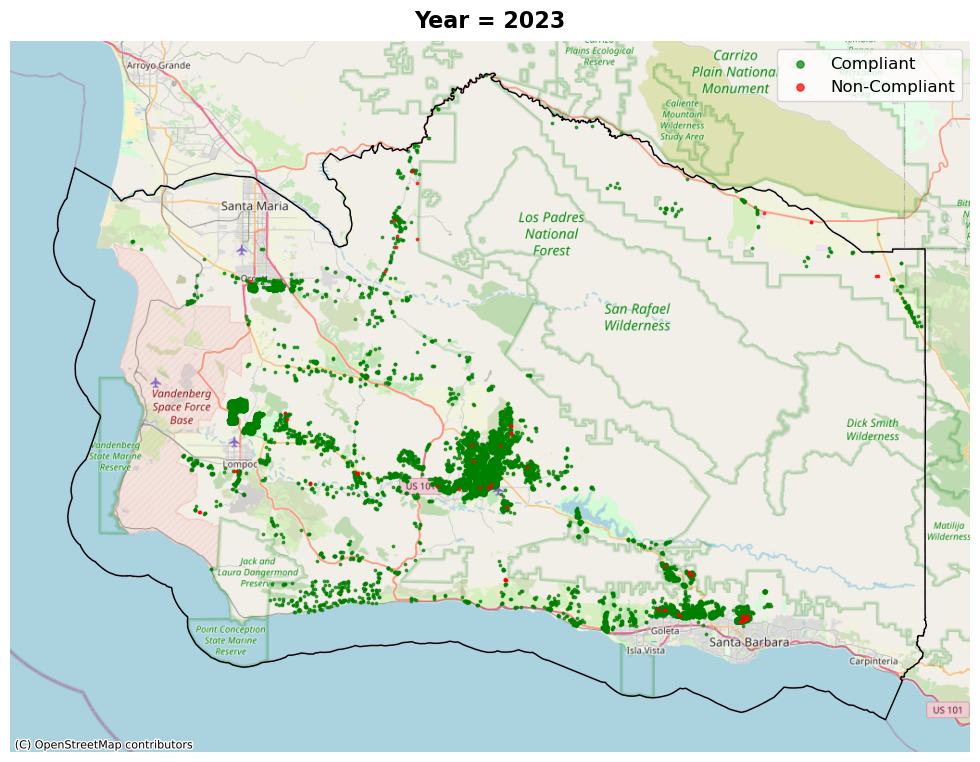

In [18]:
def create_animated_gif(years):
    """
    Create an animated GIF that cycles through each year of inspection data.
    """
    # Prepare all data (same as your original function)
    combined_parcels = []
    combined_inspections = []

    for year in years:
        # Get the joined parcels data and add year column
        parcels_df = globals()[f"joined_{year}"].copy()
        parcels_df["year"] = year
        parcels_df["data_type"] = "parcel"
        combined_parcels.append(parcels_df)

        # Get the inspections data and add year column
        insp_df = globals()[f"inspections_{year}"].copy()
        insp_df["year"] = year
        insp_df["data_type"] = "inspection"
        combined_inspections.append(insp_df)

    # Combine all years
    all_parcels = pd.concat(combined_parcels)
    all_inspections = pd.concat(combined_inspections)

    # Create figure and axis with tight layout
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.02)

    def animate(frame):
        """Animation function for each frame (year)"""
        ax.clear()

        # Get current year
        current_year = years[frame]

        # Filter data for current year
        current_parcels = all_parcels[all_parcels["year"] == current_year]
        current_inspections = all_inspections[all_inspections["year"] == current_year]

        # Convert to Web Mercator (EPSG:3857) for basemap
        parcels_3857 = current_parcels.to_crs(epsg=3857)
        insp_3857 = current_inspections.to_crs(epsg=3857)

        # Split inspections by status
        compliant = insp_3857[insp_3857["status"] == "Compliant"]
        non_compliant = insp_3857[insp_3857["status"] == "Non-Compliant"]

        # Plot each type with different colors
        if not compliant.empty:
            compliant.plot(
                ax=ax, color="green", markersize=3, label="Compliant", alpha=0.7
            )
        if not non_compliant.empty:
            non_compliant.plot(
                ax=ax, color="red", markersize=3, label="Non-Compliant", alpha=0.7
            )

        # Add county boundary
        sb_county.to_crs(epsg=3857).boundary.plot(ax=ax, color="black", linewidth=1)

        # Add basemap
        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)

        # Set title with new format
        ax.set_title(
            f"Year = {current_year}",
            fontsize=16,
            fontweight="bold",
            pad=10,
        )

        # Add legend with larger markers
        legend = ax.legend(loc="upper right", fontsize=12, markerscale=3)

        # Remove axis
        ax.axis("off")

    # Create animation
    anim = animation.FuncAnimation(
        fig,
        animate,
        frames=len(years),
        interval=1000,  # 1 second per frame
        repeat=True,
        blit=False,
    )

    # Save as GIF with tight bounding box
    anim.save(
        "/capstone/wildfire_prep/leilanie/data-preparation/figures/inspections_by_year.gif",
        writer="pillow",
        fps=0.5,
        dpi=100,
        savefig_kwargs={"bbox_inches": "tight", "pad_inches": 0.1},
    )

    print("GIF saved as 'inspections_by_year.gif'")

    # Show the animation
    plt.show()

    return anim


# Create the animated GIF
years = list(range(2019, 2024))
animation_obj = create_animated_gif(years)